## 1. Programa BEM en 3D

In [1]:
%run MAIN_MESH.py

In [2]:
import meshio

import numpy as np

from COORDINATES import COORDINATES
from ELEMENT_CONNECTION import ELEMENT_CONNECTION
from COS_DIR import COS_DIR
from MATCHING import MATCHING
from FUNDA6 import FUNDA6
from FUNDA6_TRI import FUNDA6_TRI
from GHMAT6 import GHMAT6
from ETAXJA import ETAXJA
from LOCIN6 import LOCIN6
from EXTIN6 import EXTIN6
from TRILOC6 import TRILOC6

from POROUS_NODES import POROUS_NODES

from FREE_SURFACE import FREE_SURFACE
from FAR_FIELD import FAR_FIELD
from LINEAR_BC_COMPLEX_G import LINEAR_BC_COMPLEX_G
from BC_SCATTERING import BC_SCATTERING
from FX_FUNCTION import FX_FUNCTION
from UPDATE_GUESS_HUANG_V2 import UPDATE_GUESS_HUANG_V2
from ENERGY_FLUX import ENERGY_FLUX
from NODES_FS import NODES_FS

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # activates 3D plotting

In [3]:
mesh = meshio.read("OUTER_REGION.msh")
MESH_0_POS = mesh.points
QUADS9 = mesh.cells_dict["quad9"]
PHYS_0 = mesh.cell_data_dict["gmsh:physical"]["quad9"]

MESH_0_QUADS9 = np.hstack([QUADS9, PHYS_0.reshape(-1,1)])

In [4]:
mesh = meshio.read("INNER_REGION.msh")
MESH_1_POS = mesh.points
QUADS9 = mesh.cells_dict["quad9"]
PHYS_1 = mesh.cell_data_dict["gmsh:physical"]["quad9"]

MESH_1_QUADS9 = np.hstack([QUADS9, PHYS_1.reshape(-1,1)])

In [5]:
N_struct  = 1;

In [6]:
NCONEC = 9

In [7]:
N_0 ,  NE_0 ,  KCONEC0 = COORDINATES(MESH_0_POS , MESH_0_QUADS9)
N_1 ,  NE_1 ,  KCONEC1 = COORDINATES(MESH_1_POS , MESH_1_QUADS9)

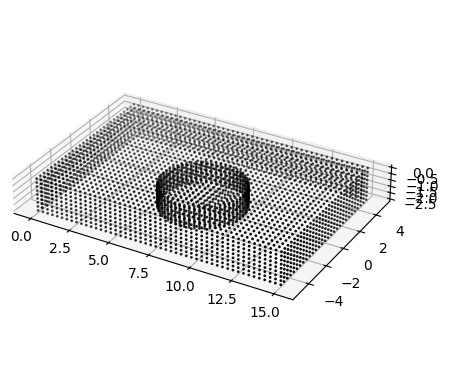

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    MESH_0_POS[:,0],
    MESH_0_POS[:,1],
    MESH_0_POS[:,2],
    c='k',
    s=1
)

#ax.grid(True)
ax.set_box_aspect([7.5,5,1])  # axis equal

plt.show()

In [9]:
# ELEMENT CONNECTION

REF_R0 , NORMAL0 = ELEMENT_CONNECTION(NCONEC , KCONEC0 , MESH_0_POS , NE_0)
REF_R1 , NORMAL1 = ELEMENT_CONNECTION(NCONEC , KCONEC1 , MESH_1_POS , NE_1)

In [10]:
# WATER DEPTH
DEPTH = abs(np.min(MESH_0_POS[:,2]))

# HALF WIDTH OF THE FLUME
WIDTH_CHANNEL = 2 * np.max(MESH_0_POS[:,1])

In [11]:
# MATCHING NODES BETWEEN TWO ADJACENT REGIONS (INTERFACE)

# CYL 1
NODES_MATCH_CYL_1 = MATCHING(REF_R0['POROUS_31'] ,  MESH_0_POS  ,  KCONEC0  ,  REF_R1['POROUS_31'] ,  MESH_1_POS  ,  KCONEC1);

# CYL 2
# NODES_MATCH_CYL_2 = MATCHING(REF_R0['POROUS_32'] ,  MESH_0_POS  ,  KCONEC0  ,  REF_R1['POROUS_32'] ,  MESH_1_POS  ,  KCONEC1);

In [12]:
N0      = N_0
N_total = N_0 + N_1

In [13]:
KCON_N_0  = KCONEC0[0:9, :]
KCON_N_01 = KCONEC1[0:9, :] + N0

KCONEC = np.hstack((KCON_N_0, KCON_N_01))

In [14]:
# FORM SYSTEM OF EQUATIONS FOR EACH REGION

# import time
# tic = time.perf_counter()
# toc = time.perf_counter()
# print("Elapsed time:", toc - tic, "seconds")

H1 , G1 = GHMAT6(MESH_1_POS , NCONEC , KCONEC1 , NE_1 , N_1 , DEPTH);

In [15]:
print(np.round(G1[0,0],4))
print(np.round(G1[-1,-1],4))

(0.0159+0j)
(0.1633+0j)


In [16]:
# Elapsed time: 36.18 seconds

In [17]:
H0 , G0 = GHMAT6(MESH_0_POS , NCONEC , KCONEC0 , NE_0 , N_0 , DEPTH);

In [18]:
# Elapsed time: 220.90 seconds

In [19]:
# MERGE H AND G MATRICES
H = np.zeros((N_total, N_total), dtype=np.complex128)
H[:N0, :N0] = H0
H[N0:N_total, N0:N_total] = H1

NE0 = NE_0
NE_total = NE_0 + NE_1

G_CONE0  = NCONEC * NE0
G_CONE01 = NCONEC * NE_total

G = np.zeros((N_total, G_CONE01), dtype=np.complex128)
G[:N0, :G_CONE0] = G0
G[N0:N_total, G_CONE0:G_CONE01] = G1

In [20]:
# READ THE POROUS NODES IN BOTH REGIONS
[STORE_NODE_R0, STORE_NODE_R1] = POROUS_NODES(NCONEC, KCONEC0, KCONEC1, MESH_0_POS, MESH_1_POS, NODES_MATCH_CYL_1);

In [21]:

gravity = 9.8056
rho = 999.1033

# FREQUENCY ITERATIONS
ttmax = 1

# WAVE PERIODS
kh = np.linspace(0.15, 0.15, ttmax)
# WAVE HEIGHT
HL = 0.01
# PARAMETERS FOR POROSITY
eps = 0.10

# NONLINEAR ITERATIONS
ITERATION = 1
# LINEAR INITIAL GUESS
Gporous = 0.5

# Preallocate if not already done
X_axis = np.zeros(ttmax)

CR = np.zeros(ttmax)
CT = np.zeros(ttmax)
KR = np.zeros(ttmax)
KT = np.zeros(ttmax)
KL = np.zeros(ttmax)

WAVE = {
    "k": np.zeros(ttmax),
    "lambda": np.zeros(ttmax),
    "HL": np.zeros(ttmax),
    "T": np.zeros(ttmax),
    "omega": np.zeros(ttmax),
    "Amp": np.zeros(ttmax)
}

Err_1 = np.zeros((ITERATION, ttmax))

# ============================
# MAIN LOOP
# ============================

for tt in range(ttmax):

    print(tt + 1)

    X_axis[tt] = kh[tt]

    # WAVE NUMBER
    k = kh[tt] / DEPTH

    # WAVE PERIOD
    T = np.sqrt((2*np.pi)**2 / (k * gravity * np.tanh(k * DEPTH)))

    # WAVE FREQUENCY
    f = 1.0 / T

    # ANGULAR FREQUENCY
    omega = 2*np.pi*f

    Wave_height = HL * (2*np.pi / k)
    Amp = Wave_height / 2

    # Store wave properties
    WAVE["k"][tt] = k
    WAVE["lambda"][tt] = 2*np.pi / k
    WAVE["HL"][tt] = Wave_height / (2*np.pi / k)
    WAVE["T"][tt] = T
    WAVE["omega"][tt] = omega
    WAVE["Amp"][tt] = Amp

    # Wall thickness
    b = 0.0254 * 1.0

    # NONLINEAR
    Gporous_str = Gporous
    l = 0.0   # b/eps if desired

    # ============================
    # NONLINEAR ITERATIONS
    # ============================

    for HHH in range(ITERATION):

        print(HHH + 1)

        # SAVE MATRICES
        A = H.copy()
        B = G.copy()

        # ------------------------
        # BOUNDARY CONDITIONS
        # ------------------------

        # FREE SURFACE
        A = FREE_SURFACE(A, B, omega, gravity, NCONEC,REF_R0["FS"], KCONEC, 0)

        # FAR FIELDS
        A = FAR_FIELD(A, B, k, NCONEC,REF_R0["IN"], KCONEC, 0)

        A = FAR_FIELD(A, B, k, NCONEC,REF_R0["OUT"], KCONEC, 0)

        # POROUS STRUCTURE BC
        A = LINEAR_BC_COMPLEX_G(A, B, NCONEC,
            STORE_NODE_R0,STORE_NODE_R1,
            0, 0, N0, NE0,
            Gporous_str, k)

        # ------------------------
        # SCATTERING VECTOR
        # ------------------------

        BC_S = BC_SCATTERING(Wave_height, k, omega, DEPTH,MESH_0_POS, KCONEC,REF_R0["IN"], NCONEC, 0, 0)

        # ------------------------
        # RHS VECTOR
        # ------------------------

        FX_S = FX_FUNCTION(NE_total, N_total, NCONEC, B, BC_S)

        # ------------------------
        # SOLVE SYSTEM
        # ------------------------

        Coef_S = np.linalg.solve(A, FX_S)

        # ------------------------
        # UPDATE Gporous
        # ------------------------

        G_old = Gporous_str

        Gporous_str = UPDATE_GUESS_HUANG_V2(Coef_S, 0, N0,
            STORE_NODE_R0,STORE_NODE_R1,
            k, omega, eps, l,Gporous_str,
            MESH_0_POS, NCONEC, MESH_1_POS
        )

        # ERROR
        Err_1[HHH, tt] = abs(Gporous_str - G_old)

    # ENERGY FLUX
    
    FI = (WIDTH_CHANNEL) * (1/8) * rho * gravity * (Wave_height**2) * (omega / k) * (
        0.5 * (1 + (2 * k * DEPTH) / np.sinh(2 * k * DEPTH))
     )

    FLUX_REFLE, FLUX_TRANS = ENERGY_FLUX(Coef_S, NCONEC, omega, rho, k, gravity, Wave_height, DEPTH,
        REF_R0["IN"],  MESH_0_POS, KCONEC0,
        REF_R0["OUT"], MESH_0_POS, KCONEC0)

    CR[tt] = np.sqrt(FLUX_REFLE / FI)
    CT[tt] = np.sqrt(FLUX_TRANS / FI)

    KR[tt] = FLUX_REFLE / FI
    KT[tt] = FLUX_TRANS / FI
    KL[tt] = 1.0 - KR[tt] - KT[tt]        

# END LOOPS



1
1


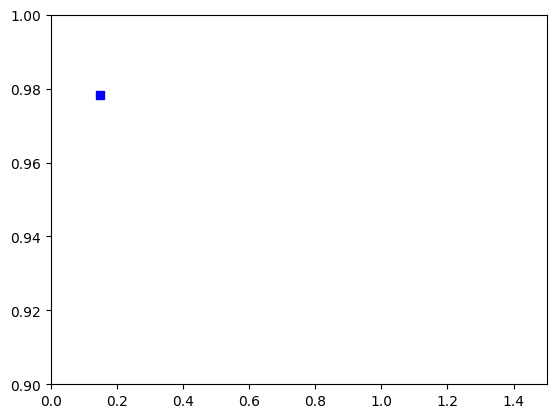

In [22]:
# figure(15)
plt.figure(15)

# plot(kh, KT, 'bs')
# 'bs' stands for blue squares
plt.plot(kh, KT, 'bs')

# xlim([0 1.5])
plt.xlim([0, 1.5])

# ylim([0 1])
plt.ylim([0.9, 1])

# Optional: display the plot
plt.show()

In [23]:
KT
# array([0.9784011])

array([0.9784011])